kaggle加州房价预测

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_data = pd.read_csv('../data/Cali_house_prices/train.csv')
test_data = pd.read_csv('../data/Cali_house_prices/test.csv')

print(train_data.shape)
print(test_data.shape)

Using device: cpu
(47439, 41)
(31626, 40)


Part 0 在本地先跑，数据量太大， 切一部分试试

In [2]:
train_data = train_data.sample(frac=0.01, random_state=42)
test_data = test_data.sample(frac=0.01, random_state=42)

print(train_data.shape)
print(test_data.shape)

(474, 41)
(316, 40)


Part1 数据预处理

1.1看一下数据的样子

In [3]:
print(train_data.iloc[0:, [0,1,2,-1,-2]])

          Id                   Address  Sold Price State    Zip
10448  10448           324 Cypress Ave   1055000.0    CA  95050
5503    5503            68 W Summit Dr   1910000.0    CA  94062
16115  16115         18009 Hillwood Ln    687375.0    CA  95037
40895  40895          2699 Yosemite Dr   1640000.0    CA  94002
7544    7544          5144 Village Grn    751000.0    CA  90016
...      ...                       ...         ...   ...    ...
13196  13196          1497 Redmond Ave   1400000.0    CA  95120
36881  36881             603 Andrew St    559000.0    CA  95605
16476  16476           205 Aberdeen Dr   2920000.0    CA  94070
14572  14572  1865 California St APT 1    799000.0    CA  94109
29465  29465           1406 Rainbow Dr   3200000.0    CA  94402

[474 rows x 5 columns]


1.2 删除id train不仅要删除id属性还要删除最后的标签， 测试集只用删除id

In [4]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
print(all_features)

                 Address  Sold Price  \
10448    324 Cypress Ave   1055000.0   
5503      68 W Summit Dr   1910000.0   
16115  18009 Hillwood Ln    687375.0   
40895   2699 Yosemite Dr   1640000.0   
7544    5144 Village Grn    751000.0   
...                  ...         ...   
20494    15311 Tacuba Dr         NaN   
1043   421 Kate Hayes St         NaN   
21929   16984 Manresa Ct         NaN   
10533  129 Windjammer Dr         NaN   
22364        28252 Yanez         NaN   

                                                 Summary          Type  \
10448  Fixer with a lot of potential!  Wonderful neig...  SingleFamily   
5503   68 W Summit Dr, Emerald Hills, CA 94062 is a s...  SingleFamily   
16115  Sunrise to sunset you will adore this elegant ...     Townhouse   
40895  Situated in the fabulous Belcrest Gardens neig...  SingleFamily   
7544   Sleek, stylish remodeled townhouse in coveted ...         Condo   
...                                                  ...           ...   
2

1,3 对数值和字符串进行预处理。
        数值进行标准化。
        字符串进行离散化处理

all_features.dtypes 返回每列的pandas数据类型（int64 float64 object）
all_features.dtypes.index 会返回对应的列名

In [5]:
num_features = all_features.dtypes[all_features.dtypes != 'object'].index
print(num_features)

Index(['Sold Price', 'Year built', 'Lot', 'Bathrooms', 'Full bathrooms',
       'Total interior livable area', 'Total spaces', 'Garage spaces',
       'Elementary School Score', 'Elementary School Distance',
       'Middle School Score', 'Middle School Distance', 'High School Score',
       'High School Distance', 'Tax assessed value', 'Annual tax amount',
       'Listed Price', 'Last Sold Price', 'Zip'],
      dtype='object')


对数值型特征进行 Z-score 标准化.
让不同尺度、不同量纲的特征在数值上具有可比性，防止某些数值范围过大的特征在后续模型中主导训练过程

all_features[num_features] 选取所有数值特征

.apply(lambda x: (x-x.mean()) / (x.std())) 对每列（每个特征）进行标准化。

x.mean() 该列均值
x.std()  该列标准差

In [6]:
all_features[num_features] = all_features[num_features].apply(
    lambda x:(x - x.mean()) / (x.std())
)

之前的步骤使每个特征的均值为0，标准差为1
后面填补缺失值，直接填0，因为每个特征的均值就是0

也可以先填补缺失值，再进行标准化。

In [7]:
all_features[num_features] = all_features[num_features].fillna(0)

开始对字符串进行预处理，处理离散值，使用独热编码替换

pd.get_dummies 会将分类特征(通常为字符串/object)转换为一组 0/1的变量

dummy_na = True 可以标记缺失值，用于保留信息

In [8]:
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features = all_features * 1

all_features.shape

(790, 5752)

4.拆回去

In [9]:
n_train = train_data.shape[0]

train_features = torch.tensor(all_features[:n_train].values,
                             dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values,
                            dtype=torch.float32)
train_labels = torch.tensor(train_data['Sold Price'].values.reshape(-1,1),
                           dtype=torch.float32)

5. 训练

In [10]:
loss = nn.MSELoss()
in_features = train_features.shape[1]
print(in_features)

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    net.to(device)
    return net

5752


In [11]:
# 用于计算每个 epoch 的模型表现
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    
    return rmse.item()

In [12]:
def train(net, train_features, train_labels, test_features,
         test_labels, num_epochs, lr, weight_decay, batch_size):
    
    train_ls, test_ls = [], []
    
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    
    optimizer = torch.optim.Adam(net.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    
    return train_ls, test_ls 

In [13]:
def get_k_fold_data(k, i, X, y):
    assert k > 1 
    fold_size = X.shape[0] // k
    
    X_train, y_train = None, None
    
    for j in range(k):
        # 取出第 j 折的索引
        idx = slice(j * fold_size, (j+1) * fold_size)
        # 取出 第 j 折 的数据
        X_part, y_part = X[idx, :], y[idx]
        if j == i:  # 第 i 折作为验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None: # 训练集还是空的 → 第一次遇到训练折，直接把这一折当作初始训练集
            X_train, y_train =X_part, y_part
        else:  # 训练集已经有一部分了 → 把当前的折拼接到已有的训练集后面
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
        
    return X_train, y_train, X_valid, y_valid

In [14]:
def k_fold(k, X_train, y_train, num_epochs, lr,
           weight_decay, batch_size):
    
    train_l_sum, valid_l_sum = 0, 0
    
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs,
                                  lr, weight_decay, batch_size)
        
        train_l_sum += train_ls[-1]
        valid_l_sum =+ valid_ls[-1]
        
        if i == 0 :
            d2l.plot(list(range(1, num_epochs + 1)),
                    [train_ls, valid_ls],
                    xlabel='epoch', ylabel='rmse',
                    xlim=[1, num_epochs],
                    legend=['train','valid'],
                    yscale='log')
        print(f'fold{i + 1}, train log rmse {float(train_ls[-1]):f}',
              f'valid log rmse {float(valid_ls[-1]):f}')
        

    return train_l_sum / k, valid_l_sum / k

fold1, train log rmse 3.013539 valid log rmse 2.927910
fold2, train log rmse 3.041944 valid log rmse 3.697258
fold3, train log rmse 2.977914 valid log rmse 3.147511
fold4, train log rmse 3.030628 valid log rmse 3.803816
fold5, train log rmse 2.986930 valid log rmse 3.211266
fold6, train log rmse 3.097910 valid log rmse 3.248976
fold7, train log rmse 3.049279 valid log rmse 3.693032
fold8, train log rmse 2.984406 valid log rmse 3.976283
fold9, train log rmse 2.987377 valid log rmse 3.675927
fold10, train log rmse 3.052370 valid log rmse 3.094734
10-折验证：平均训练log rmse:3.022230 平均验证log rmse：0.309473


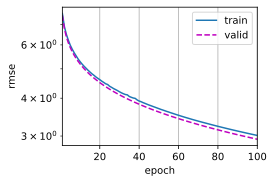

In [15]:
k, num_epochs, lr, weight_decay, batch_size = 10, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                         weight_decay, batch_size)
print(f'{k}-折验证：平均训练log rmse:{float(train_l):f}',
      f'平均验证log rmse：{float(valid_l):f}')

train log rmse 2.995353


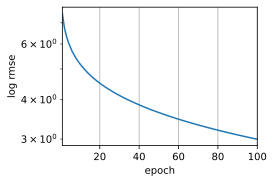

In [16]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                  num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                       num_epochs, lr, weight_decay, batch_size)
    
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
            ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    
    print(f'train log rmse {float(train_ls[-1]):f}')
    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv',index=False)
    
train_and_pred(train_features, test_features, train_labels, test_data,
              num_epochs, lr, weight_decay, batch_size)
